In [1]:
import csv
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import leastsq

In [2]:
def parse_clipboard_data(text):
    """
    Converts tabular text input (e.g. from copy-pasting) into x and y NumPy arrays.
    Assumes tab or space-separated two-column data.
    """
    # Split lines and filter out empty lines
    lines = [line.strip() for line in text.strip().splitlines() if line.strip()]
    # Split each line by whitespace or tab
    data = [list(map(float, line.split())) for line in lines]
    arr = np.array(data)
    return arr

In [201]:
def single_gaussian(x,params):
    (c1, mu1, sigma1, b) = params
    res =   b + c1 * np.exp( - (x - mu1)**2.0 / (2.0 * sigma1**2.0) ) 
    return res

def double_gaussian(x, params):
    (c1, mu1, sigma1, c2, mu2, sigma2,b) = params
    res =  b + c1 * np.exp( - (x - mu1)**2.0 / (2.0 * sigma1**2.0) ) \
          + c2 * np.exp( - (x - mu2)**2.0 / (2.0 * sigma2**2.0) )
    return res

def single_gaussian_fit(params,x,y):
    fit = single_gaussian(x, params)
    return (fit - y)

def double_gaussian_fit(params, x, y):
    fit = double_gaussian(x, params)
    return (fit - y)

def triple_gaussian(x, params):
    (c1, mu1, sigma1, c2, mu2, sigma2, c3, mu3, sigma3, b) = params
    return (
        b 
        + c1 * np.exp(-((x - mu1) ** 2.0) / (2.0 * sigma1 ** 2.0))
        + c2 * np.exp(-((x - mu2) ** 2.0) / (2.0 * sigma2 ** 2.0))
        + c3 * np.exp(-((x - mu3) ** 2.0) / (2.0 * sigma3 ** 2.0))
    )

def triple_gaussian_fit(params, x, y):
    fit = single_gaussian(x, params)
    return fit - y


#### lorentzians ####

def single_lorentzian(x, params):
    (c1, mu1, gamma1, b) = params
    res = b + c1 * (gamma1**2.0 / ((x - mu1)**2.0 + gamma1**2.0))
    return res

def single_lorentzian_fit(params, x, y):
    fit = single_lorentzian(x, params)
    return (fit - y)

def double_lorentzian(x, params):
    (c1, mu1, gamma1, c2, mu2, gamma2, b) = params
    return (
        b + c1 * (gamma1 ** 2.0 / ((x - mu1) ** 2.0 + gamma1 ** 2.0))
        + c2 * (gamma2 ** 2.0 / ((x - mu2) ** 2.0 + gamma2 ** 2.0))
    )

def double_lorentzian_fit(params, x, y):
    fit = double_lorentzian(x, params)
    return fit - y


def triple_lorentzian(x, params):
    (c1, mu1, gamma1, c2, mu2, gamma2, c3, mu3, gamma3, b) = params
    return (
        b + c1 * (gamma1 ** 2.0 / ((x - mu1) ** 2.0 + gamma1 ** 2.0))
        + c2 * (gamma2 ** 2.0 / ((x - mu2) ** 2.0 + gamma2 ** 2.0))
        + c3 * (gamma3 ** 2.0 / ((x - mu3) ** 2.0 + gamma3 ** 2.0))
    )

def triple_lorentzian_fit(params, x, y):
    fit = single_lorentzian(x, params)
    return fit - y

In [3]:
raw_data = """
0	514.552	888.464	646.218	638.905	0	0
1	422.454	713.595	680.347	611.782	45.945	0
2	331.982	790.554	708.658	568.197	57.019	0
3	333.316	760.247	610.35	584.732	0	0
4	348.12	757.16	632.782	672.29	60.854	0
5	471.723	998.843	750.916	736.655	237.747	0
6	568.298	1268.137	768.639	693.865	87.123	0
7	579.475	1450.021	863.828	870.946	1.779	0
8	803.538	1741.794	1101.302	1138.944	0	0
9	1269.802	2398.322	1454.786	1452.091	127.093	162.677
10	1959.584	3308.751	1993.898	2028.246	840.708	1222.654
11	3431.642	4786.502	2598.168	3013.659	1649.127	2895.084
12	6633.51	7150.855	5154.638	5376.246	5177.794	4963.455
13	13042.658	10239.554	10377.488	9079.87	11409.532	7929.69
14	20653.055	13716.044	17234.031	13083.152	16133.959	11413.977
15	23804.014	15858.484	22670.133	14354.331	21885.059	12923.624
16	18836.668	15091.918	18055.535	12394.138	18323.594	11483.367
17	12153.811	12344.651	9046.715	8890.879	10195.664	8687.329
18	8533.912	9396.738	5007.844	5699.231	5224.543	6342.199
19	7135.051	7284.163	3948.666	4005.397	5269.063	4140.754
20	5419.432	5529.533	2856.85	3116.043	2459.049	2649.694
21	3744.445	4279.702	2668.459	2671.628	3005.803	1817.074
22	2982.397	3469.559	2348.405	2255.934	1675.955	1245.32
23	2745.478	2870.001	2222.542	1985.608	2647.163	750.008
24	2476.469	2386.041	2104.853	1768.76	864.116	478.808
25	2635.338	2010.87	2057.923	1609.005	1347.821	282.477
26	3031.228	1719.263	2300.807	1400.691	2006.001	23.914
27	2693.792	1450.596	2072.041	1248.416	1873.931	0
28	1579.813	1325.77	1691.26	1153.151	153.796	0
29	839.628	1339.254	1655.894	1061.029	180.011	0
30	700.519	1284.744	1506.984	1056.042	18.175	0
31	786.234	1282.784	1540.39	1057.798	777.665	0


"""

In [5]:
arr = parse_clipboard_data(raw_data)
print(arr.shape)

(32, 7)


In [14]:
pxSize = 28
x = arr[:,0] 
x = x * pxSize

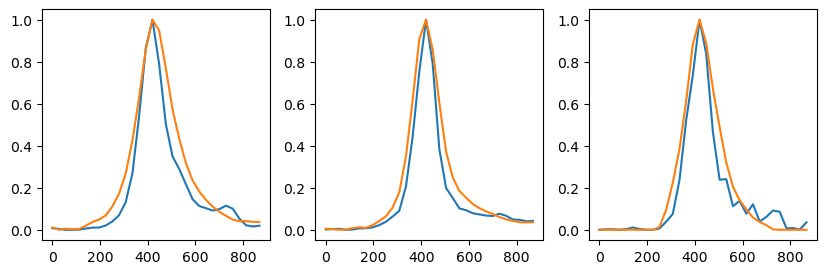

In [19]:

fig,axs = plt.subplots(1,3,figsize=(10,3))
for i in range(1,arr.shape[1]):
    ax = axs[(i-1)//2]
    y = arr[:,i]
    y=(y-np.min(y))/(np.max(y)-np.min(y))  # Normalize y
    # print(y)
    ax.plot(x,y)

plt.show()


FWHM1: 91.39


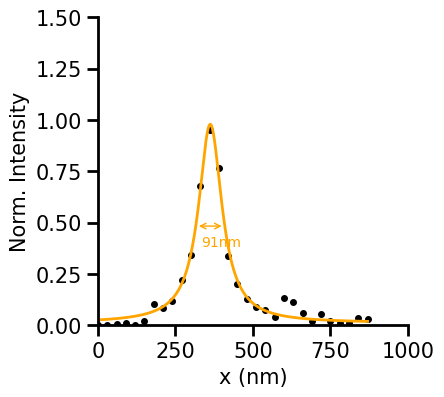

In [ ]:
fit_choice = "lorentz"

x2 = np.linspace(min(x),max(x),1000)

params = [
    1.0,350,60,
    0.3
]

# Least squares fit. 
fit_gauss = leastsq(single_gaussian_fit, params, args=(x, y))
fit_lorentz = leastsq(single_lorentzian_fit, params, args=(x, y))

if fit_choice == "gauss":
    fit = fit_gauss
    fwhm_factor = 2.35
else:
    fit = fit_lorentz
    fwhm_factor = 2

# Extract parameters
params1 = fit[0][:3]
bckg = fit[0][-1]

# Calculate FWHM for each Gaussian
fwhm1 = fwhm_factor * abs(params1[2])


fig = plt.figure(figsize=(4, 4))

# Plot data and fit
if fit_choice == "gauss":
    func = single_gaussian
else:
    func = single_lorentzian

plt.plot(x, y, 'ko', markersize=4)
plt.plot(x2, func(x2, fit[0]), 'orange', linewidth=2)

# Annotate FWHM on the plot
plt.text(params1[1]-30, params1[0] / 2-0.1, f'{fwhm1:.0f}nm', color='orange')

# Add double-sided arrows for FWHM
plt.annotate('', xy=(params1[1] - fwhm1 / 2, params1[0] / 2), 
             xytext=(params1[1] + fwhm1 / 2, params1[0] / 2),
             arrowprops=dict(arrowstyle='<->', color='orange'))


# plot values
w1 = fit[0][2]

# FWHM
if fit_choice == "gauss":
    fwhm1 = 2.355 * abs(w1)
else:  # lorentzian
    fwhm1 = 2.0 * abs(w1)
print(f"FWHM1: {fwhm1:.2f}")


labels_fontSize=15
ticks_prms={"labelsize":15, "width":2,"length":8}

plt.xlabel('x (nm)',fontsize=labels_fontSize)
plt.ylabel('Norm. Intensity',fontsize=labels_fontSize)

plt.xlim(0, 1000)
plt.ylim(0, 1.5)


plt.tick_params(axis='x',which='major',**ticks_prms)
plt.tick_params(axis='y',which='major',**ticks_prms)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_linewidth(2)
plt.gca().spines['bottom'].set_linewidth(2)


plt.show()


In [205]:

# fig.savefig("lineProfile_GTvim.svg", format="svg", bbox_inches='tight')